### ***Project # 6***

#### ***Objective***

***To identify different segments in the existing customer, based on their spending patterns as well as past interaction with the bank, using clustering algorithms, and provide recommendations to the bank on how to better market to and service these customers.***

#### ***Data Dictionary***

- `Sl_No`: Primary key of the records
- `Customer Key`: Customer identification number
- `Average Credit Limit`: Average credit limit of each customer for all credit cards
- `Total credit cards`: Total number of credit cards possessed by the customer
- `Total visits bank`: Total number of visits that customer made (yearly) personally to the bank
- `Total visits online`: Total number of visits or online logins made by the customer (yearly)
- `Total calls made`: Total number of calls made by the customer to the bank or its customer service department (yearly)

#### ***Import Necessary Libraries***

In [1]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# to scale the data using z-score
from sklearn.preprocessing import StandardScaler

# to compute distances
from scipy.spatial.distance import cdist

# to perform k-means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# to visualize the elbow curve and silhouette scores
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

# to compute distances
from scipy.spatial.distance import pdist

# to perform hierarchical clustering, compute cophenetic correlation, and create dendrograms
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)
# Sets the precision of displayed floats to 3 decimal places
pd.set_option("display.precision", 3)

#### ***Dataset Load and Review***

In [2]:
# loading the dataset
data = pd.read_excel("data/42_CreditCardCustomerData.xlsx")

In [3]:
data.shape

(660, 7)

In [4]:
df = data.copy()

In [5]:
# find datatypes and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Sl_No                660 non-null    int64
 1   Customer Key         660 non-null    int64
 2   Avg_Credit_Limit     660 non-null    int64
 3   Total_Credit_Cards   660 non-null    int64
 4   Total_visits_bank    660 non-null    int64
 5   Total_visits_online  660 non-null    int64
 6   Total_calls_made     660 non-null    int64
dtypes: int64(7)
memory usage: 36.2 KB


***Total 7 columns, all numeric, no null values***

In [6]:
# view random sample of 10 rows
df.sample(n=10, random_state=1)

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
547,548,38125,26000,4,5,2,4
353,354,94437,9000,5,4,1,3
499,500,65825,68000,6,4,2,2
173,174,38410,9000,2,1,5,8
241,242,81878,10000,4,5,1,3
341,342,70779,18000,4,3,2,0
647,648,79953,183000,9,0,9,2
218,219,28208,19000,3,1,5,7
120,121,16577,10000,4,2,4,6
134,135,31256,13000,4,1,5,7


In [7]:
# check for number of unique values in each column
df.nunique()

Sl_No                  660
Customer Key           655
Avg_Credit_Limit       110
Total_Credit_Cards      10
Total_visits_bank        6
Total_visits_online     16
Total_calls_made        11
dtype: int64

***Statistical Summary***

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Sl_No,660.0,330.500,190.670,1.0,165.75,330.5,495.25,660.0
Customer Key,660.0,55141.444,25627.772,11265.0,33825.25,53874.5,77202.50,99843.0
Avg_Credit_Limit,660.0,34574.242,37625.488,3000.0,10000.00,18000.0,48000.00,200000.0
Total_Credit_Cards,660.0,4.706,2.168,1.0,3.00,5.0,6.00,10.0
Total_visits_bank,660.0,2.403,1.632,0.0,1.00,2.0,4.00,5.0
Total_visits_online,660.0,2.606,2.936,0.0,1.00,2.0,4.00,15.0
Total_calls_made,660.0,3.583,2.865,0.0,1.00,3.0,5.00,10.0


- *`Avg_Credit_Limit` - Average Credit Limit is 34,574, medium credit limit is 18,000. Data is right skewed. Maximum average credit limit is 200,000*
- *`Total_Credit_Cards` - Custumers have average of 4.7 cars. Minimim credit card is 1 and maximum is 10*
- *`Total_visits_bank` - Average number of bank visit is 2.4. Some customers never visited bank and maximum visit is 5 in a year*
- *`Total_visits_online` - Average number of online visit is 2.6. Some customers never logged online and maximum online visit is 15*
- *`Total_calls_made` - Customers made average of 3.58 calls. Some customers did not make any calls. Maximum calls are 10 in year*

#### ***Exploratory Data Analysis***

***Univariate Analysis***

***Helper Function to create Boxplot, Histogram and CDF plot***

In [9]:
# function to analyze a single numeric feature, creates boxplot, histogram, and CDF
def univariate_num_analysis_box_hist_cdf(data, feature, figsize=(8, 4)):
    """
    Display:
      - Left column: Boxplot (top) and Histogram (bottom)
      - Right column: CDF plot
    for a single numeric feature.
    
    Parameters:
    - data : pandas DataFrame
    - feature : str, numeric column name
    - figsize : tuple, figure size
    """
    fig = plt.figure(figsize=figsize)
    # Create grid: 2 rows, 2 columns
    grid = fig.add_gridspec(2, 2, width_ratios=(3, 2), height_ratios=(0.4, 1))

    # 1Boxplot (top left)
    ax_box = fig.add_subplot(grid[0, 0])
    sns.boxplot(data=data, x=feature, ax=ax_box, showmeans=True, color="lightgreen")
    ax_box.set_title(f'Boxplot of {feature}')

    # Histogram (bottom left)
    ax_hist = fig.add_subplot(grid[1, 0])
    sns.histplot(data=data, x=feature, kde=True, ax=ax_hist, color='skyblue')
    ax_hist.axvline(data[feature].mean(), color="green", linestyle="--", label="Mean")
    ax_hist.axvline(data[feature].median(), color="black", linestyle="-", label="Median")
    ax_hist.set_title(f'Histogram of {feature}')
    ax_hist.legend()

    # CDF Plot (right column, spans both rows)
    ax_cdf = fig.add_subplot(grid[:, 1])  # span both rows in column 2
    sns.ecdfplot(data=data, x=feature, ax=ax_cdf, color='orange')
    ax_cdf.set_title(f'CDF of {feature}')
    ax_cdf.set_ylabel("Cumulative Probability")
    ax_cdf.grid(True)

    plt.tight_layout()
    plt.show()

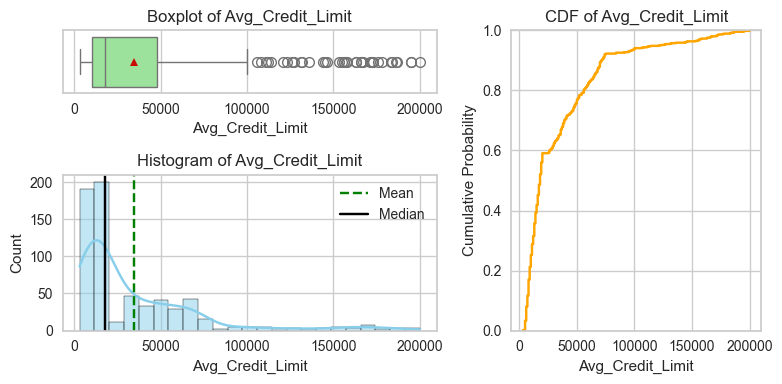

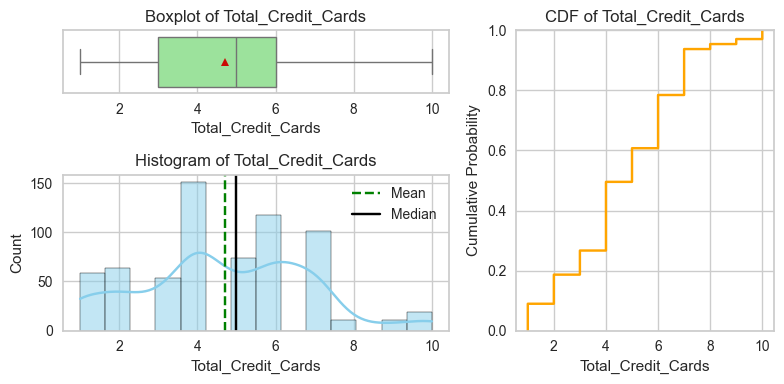

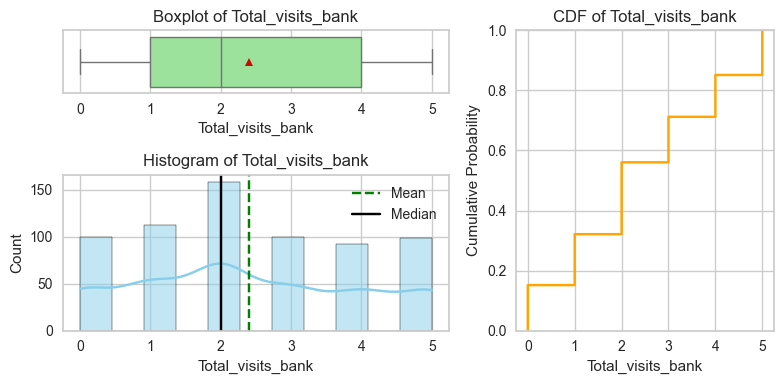

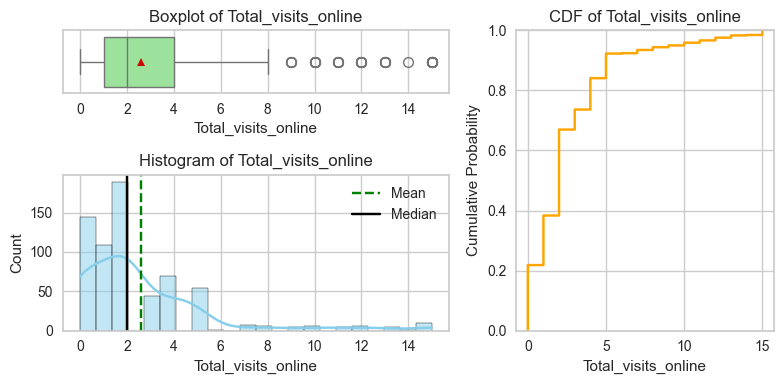

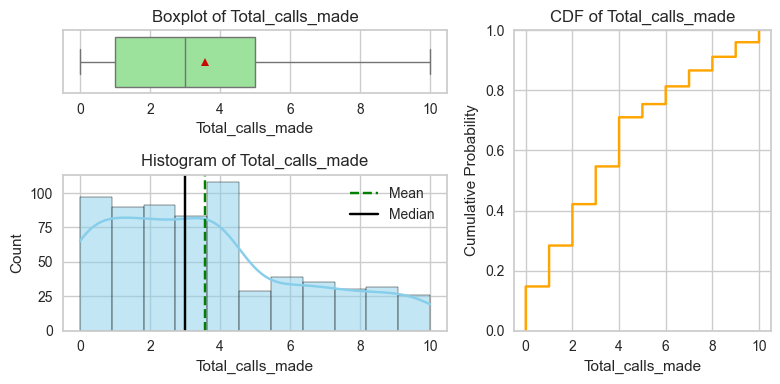

In [10]:
# selecting numerical columns
num_cols = [
    "Avg_Credit_Limit",
    "Total_Credit_Cards",
    "Total_visits_bank",
    "Total_visits_online",
    "Total_calls_made",
]

for item in num_cols:
    univariate_num_analysis_box_hist_cdf(df, item)

- *`Avg_credit_limit` is right skewed with long tail. Outliers have higher than 100K credit limit*
- *`Total_credit_cards` distribution is bimodal with peaks around 4 and 6 cards*
- *`Total_Bank_Visit` Most of the customers have visited 2 times to the bank. Other visits are uniformly distributed*
- *`Total_Visits_online` Online visit is right skewed. There are customers who have visited more than 8 and are outliers*
- *`Total_calls_made` Majority of customers have made between 0 to 4 calls*

***Bivariate analysis***

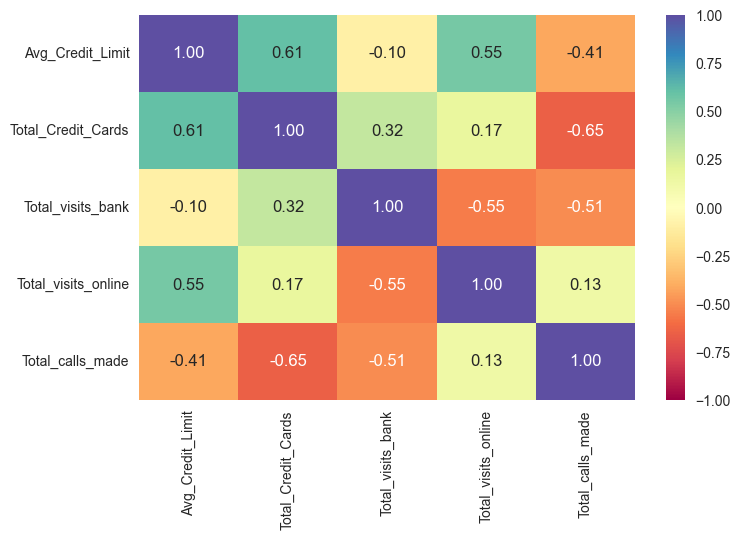

In [11]:
plt.figure(figsize=(8, 5))
sns.heatmap(
    df[num_cols].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

- *Total number of Credit Cards is positively correlated to Average credit limit. Total number of online Visit is also positively correlated to Average Credit Limit*
- *Total Calls made is negatively correlated to Average Credit limit, total number of credit cards and Total visit to banks.*
- *Also Total visit to the bank is negatively correlated to total number of ban visits and slightly negatively correlated to Average Credit Limit and positively correlated to total credit cards*

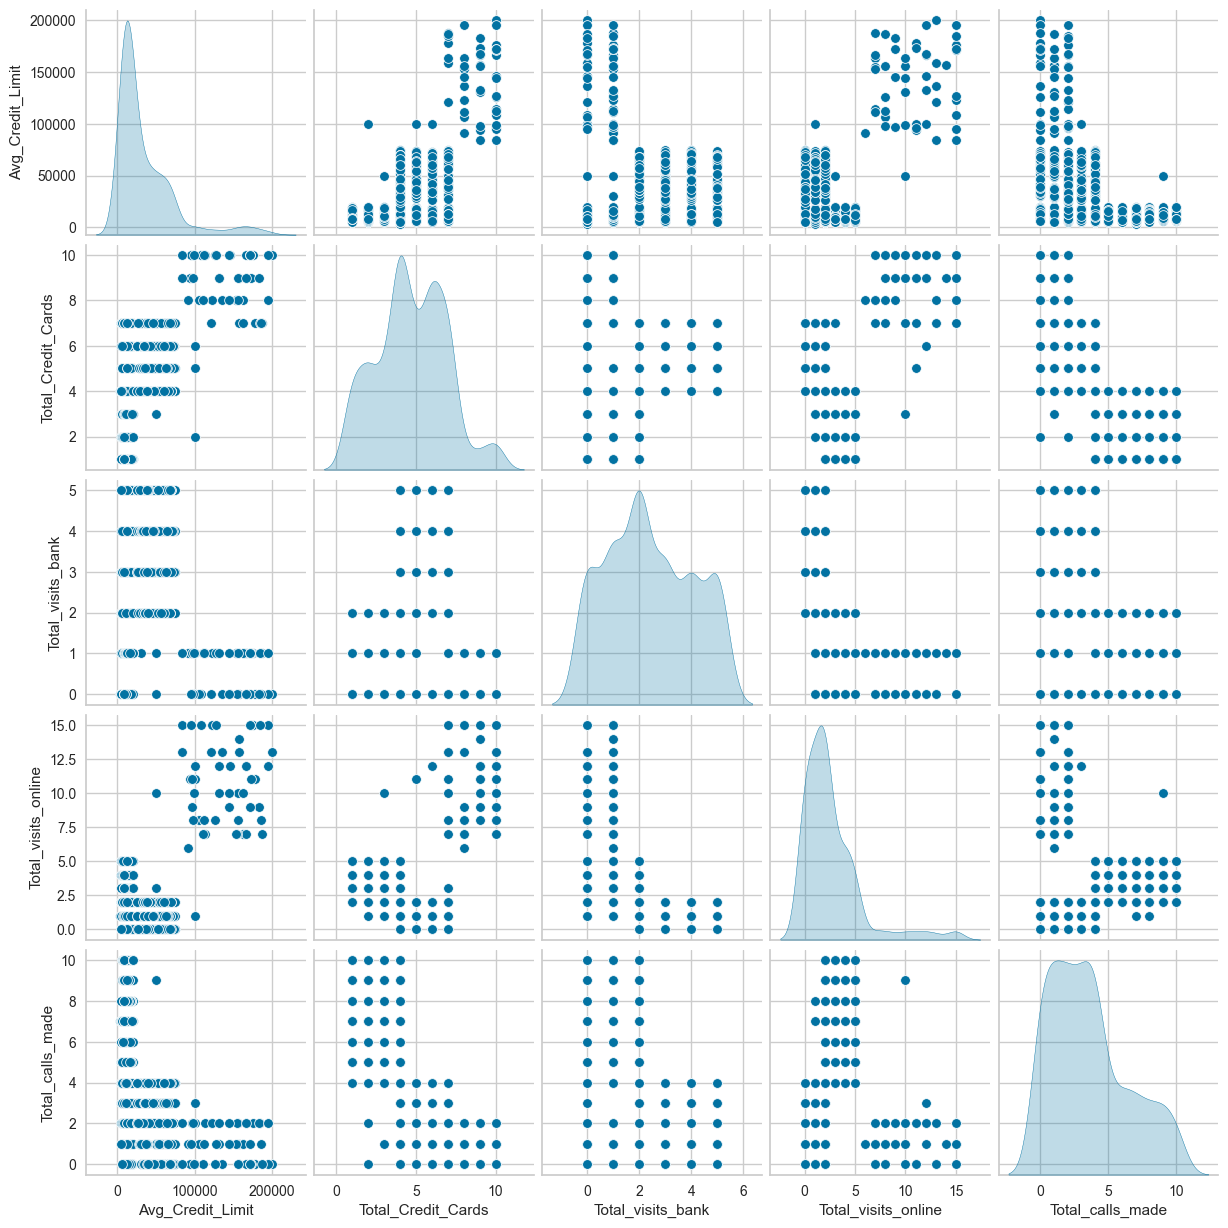

In [12]:
sns.pairplot(data=df[num_cols], diag_kind="kde")
plt.show()

- *Total number of online visits is also positively correlated to total number of credit cards* 
- *Total visits online and Avg credit limit plot clearly shows 2 clusters, similarly total visits online and total credit cards shows 2 clusters*
- *Individual histograms for total credit cards and total bank visits clearly shows multiple groups of data*

#### ***Data preprocessing***

***Drop Sl_No which is sequence number***

In [13]:
df.drop("Sl_No", axis=1, inplace=True)

***Check for duplicate rows***

In [14]:
df.duplicated().sum()

np.int64(0)

***There are no duplicate rows***

In [15]:
# df.drop("Customer Key", axis=1, inplace=True)

***Check for missing Values***

In [16]:
df.isna().sum()

Customer Key           0
Avg_Credit_Limit       0
Total_Credit_Cards     0
Total_visits_bank      0
Total_visits_online    0
Total_calls_made       0
dtype: int64

***There are no missing values***

***Checking for Outliers***

In [17]:
# to find the 25th percentile and 75th percentile for the numerical columns
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)

# Inter Quantile Range (75th percentile - 25th percentile)
IQR = Q3 - Q1

# Finding lower and upper bounds for all values. All values outside these bounds are outliers
lower_whisker = Q1 - 1.5 * IQR
upper_whisker = Q3 + 1.5 * IQR

# Percentage of outliers in each column
(
    ((df[num_cols] < lower_whisker) | (df[num_cols] > upper_whisker)).sum()
    / df.shape[0]
    * 100
).sort_values(ascending=False)

Avg_Credit_Limit       5.909
Total_visits_online    5.606
Total_Credit_Cards     0.000
Total_visits_bank      0.000
Total_calls_made       0.000
dtype: float64

***We are not going to treat outliers since these are valid values.*** 

***Feature Scaling - Standard Scaler - Applying before Clustering***

In [18]:
# scaling the dataset before clustering
scaler = StandardScaler()
subset = df[num_cols].copy()
subset_scaled = scaler.fit_transform(subset)

# creating a dataframe of the scaled columns
subset_scaled_df = pd.DataFrame(subset_scaled, columns=subset.columns)
subset_scaled_df.head()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1.740,-1.249,-0.860,-0.547,-1.252
1,0.410,-0.788,-1.474,2.521,1.892
2,0.410,1.059,-0.860,0.134,0.146
3,-0.122,0.136,-0.860,-0.547,0.146
4,1.740,0.597,-1.474,3.202,-0.204


In [19]:
# saving original dataframes for Hierarchical clustering later
df_hca = df.copy()
subset_scaled_df_hca = subset_scaled_df.copy()

In [20]:
df_hca.head()

,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,87073,100000,2,1,1,0
1,38414,50000,3,0,10,9
2,17341,50000,7,1,3,4
3,40496,30000,5,1,1,4
4,47437,100000,6,0,12,3


In [21]:
subset_scaled_df_hca.head()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1.740,-1.249,-0.860,-0.547,-1.252
1,0.410,-0.788,-1.474,2.521,1.892
2,0.410,1.059,-0.860,0.134,0.146
3,-0.122,0.136,-0.860,-0.547,0.146
4,1.740,0.597,-1.474,3.202,-0.204


#### ***Clustering***

#### ***K-means Clustering***

***First step is to determine the optimal number of groups. We will use `Elbow Method` to find optimal number of clusters***

***We will use 2 methods***
- ***Plot Distortions and Number of Clusters***
- ***Plot WCSS (Within-Cluster Sum of Squares) with Number of Clusters***

Distortions:
Number of Cluster: 1; Distortion:  2.007
Number of Cluster: 2; Distortion:  1.718
Number of Cluster: 3; Distortion:  1.147
Number of Cluster: 4; Distortion:  1.046
Number of Cluster: 5; Distortion:  0.998
Number of Cluster: 6; Distortion:  0.943
Number of Cluster: 7; Distortion:  0.923
Number of Cluster: 8; Distortion:  0.894


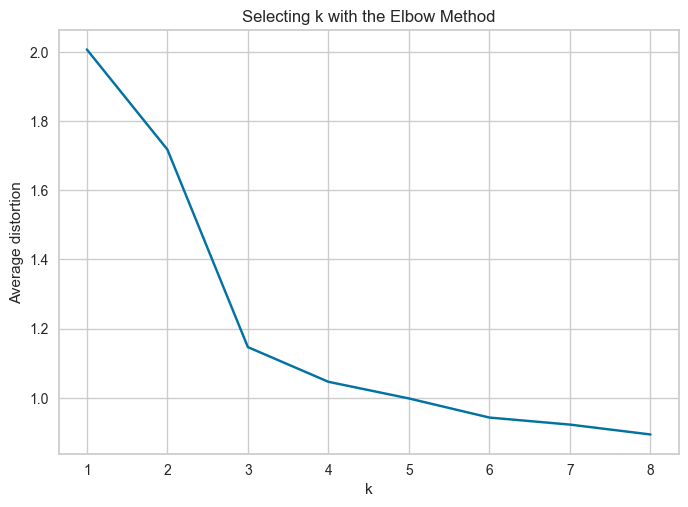

In [22]:
clusters = range(1, 9)
meanDistortions = []
wcss = []

for k in clusters:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(subset_scaled_df)
    prediction = model.predict(subset_scaled_df)
    distortion = (
        sum(
            np.min(cdist(subset_scaled_df, model.cluster_centers_, "euclidean"), axis=1)
        )
        / subset_scaled_df.shape[0]
    )

    meanDistortions.append(distortion)
    wcss.append(model.inertia_)


# print distortions and value of k
print("Distortions:")
for i, distortion in enumerate(meanDistortions):
    print(f"Number of Cluster: {clusters[i]}; Distortion:  {round(distortion, 3)}")

plt.plot(clusters, meanDistortions, "bx-")
plt.xlabel("k")
plt.ylabel("Average distortion")
plt.title("Selecting k with the Elbow Method")
plt.show()

- *Distortion decreases as the number of clusters increases - which is expected*
- *Each additional cluster allows the model to better fit the data, reducing average distance to centroids*
- *In the current scenario - from 1 to 3, distortion drops sharply `2 -> 1.71 -> 1.47` then it becomes gradual - **Diminishing Returns***


WCSS (Inertia):
Number of Cluster: 1; WCSS: 3300.0
Number of Cluster: 2; WCSS: 2138.634
Number of Cluster: 3; WCSS: 933.044
Number of Cluster: 4; WCSS: 780.774
Number of Cluster: 5; WCSS: 717.496
Number of Cluster: 6; WCSS: 642.566
Number of Cluster: 7; WCSS: 619.173
Number of Cluster: 8; WCSS: 584.447


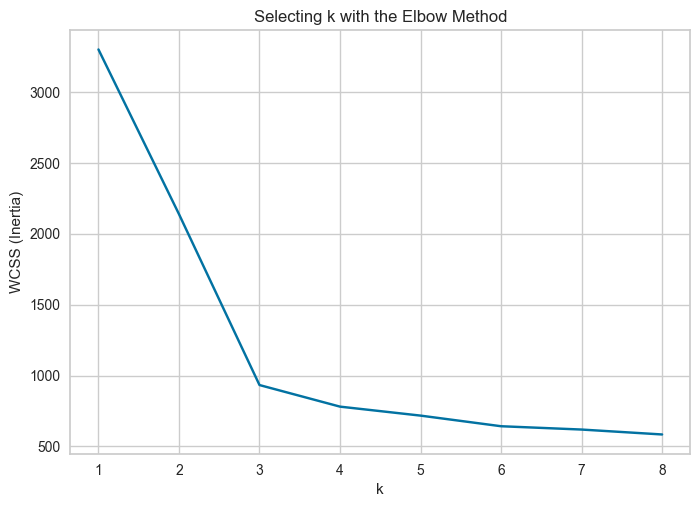

In [23]:
# print wcss values
print("\nWCSS (Inertia):")
for i, wcss_value in enumerate(wcss):
    print(f"Number of Cluster: {clusters[i]}; WCSS: {round(wcss_value, 3)}")

plt.plot(clusters, wcss, "bx-")
plt.xlabel("k")
plt.ylabel("WCSS (Inertia)")
plt.title("Selecting k with the Elbow Method")
plt.show()

- *Lower WCSS means tighter clusters (Points are closer to their Centroids)*
- *As Number of clusters increases, WCSS decreases - but with diminishing returns*

***Elbow is seen at K = 3***

***Silhouette score***

*Silhouette score is one of the methods for evaluating the quality of clusters created using clustering algorithms such as K-Means. The silhouette score is a measure of how similar an object is to its own cluster (cohesion) compared to other clusters (separation). Silhouette score has a range of [-1, 1].*

- *Silhouette coefficients near +1 indicate that the sample is far away from the neighboring clusters.*
- *Silhouette score near -1 indicate that those samples might have been assigned to the wrong cluster.*

For n_clusters = 2, the silhouette score is 0.41842496663230416)
For n_clusters = 3, the silhouette score is 0.5157182558882754)
For n_clusters = 4, the silhouette score is 0.3556670619377371)
For n_clusters = 5, the silhouette score is 0.3560795471685452)
For n_clusters = 6, the silhouette score is 0.243622999879193)
For n_clusters = 7, the silhouette score is 0.24811941448008792)
For n_clusters = 8, the silhouette score is 0.2257534140084145)
For n_clusters = 9, the silhouette score is 0.19077248576909164)


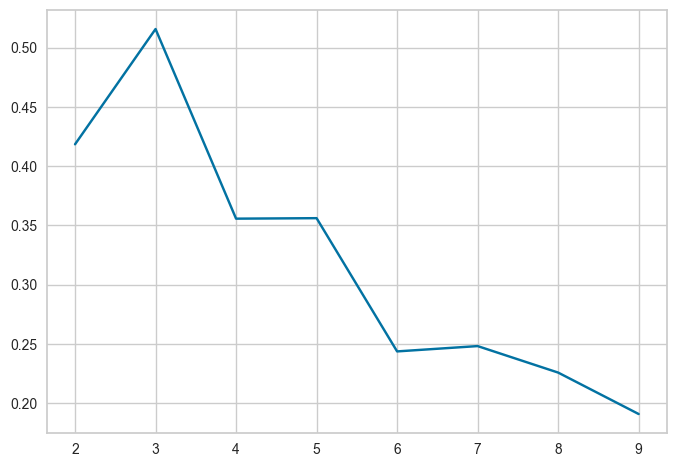

In [24]:
sil_score = []
cluster_list = list(range(2, 10))
for n_clusters in cluster_list:
    clusterer = KMeans(n_clusters=n_clusters)
    preds = clusterer.fit_predict((subset_scaled_df))
    # centers = clusterer.cluster_centers_
    score = silhouette_score(subset_scaled_df, preds)
    sil_score.append(score)
    print("For n_clusters = {}, the silhouette score is {})".format(n_clusters, score))

plt.plot(cluster_list, sil_score)
plt.show()

***Silhouette score for 3 is highest. So, we will choose 3 as value of k.***

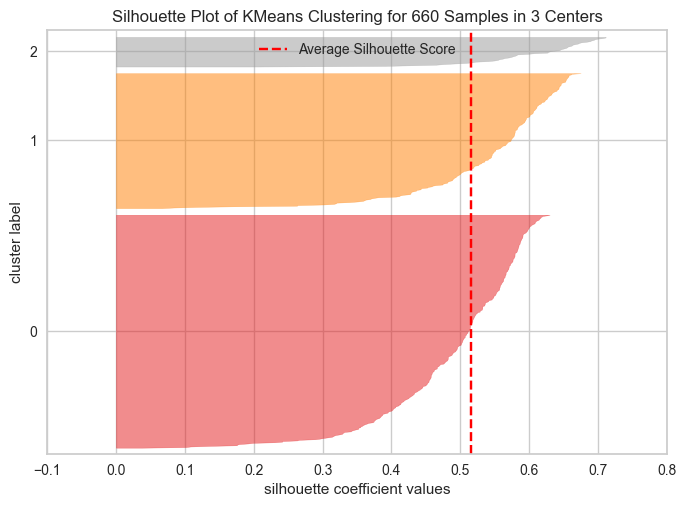

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 660 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [25]:
# finding optimal no. of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(3, random_state=1))
visualizer.fit(subset_scaled_df);
visualizer.show()

In [26]:
# let's take 3 as number of clusters
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(subset_scaled_df)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [27]:
# adding kmeans cluster labels to the original and scaled dataframes

df["K_means_segments"] = kmeans.labels_
subset_scaled_df["K_means_segments"] = kmeans.labels_

#### ***Cluster Profiling based on K Means***

In [28]:
cluster_profile = df.groupby("K_means_segments").mean()

In [29]:
cluster_profile["count_in_each_segments"] = (
    df.groupby("K_means_segments")["Total_visits_bank"].count().values
)

In [30]:
# let's display cluster profiles
cluster_profile.style.highlight_max(color="lightgreen", axis=0)

,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,count_in_each_segments
K_means_segments,,,,,,,
0,54881.329016,33782.383420,5.515544,3.489637,0.981865,2.000000,386
1,56708.760000,141040.000000,8.740000,0.600000,10.900000,1.080000,50
2,55239.830357,12174.107143,2.410714,0.933036,3.553571,6.870536,224


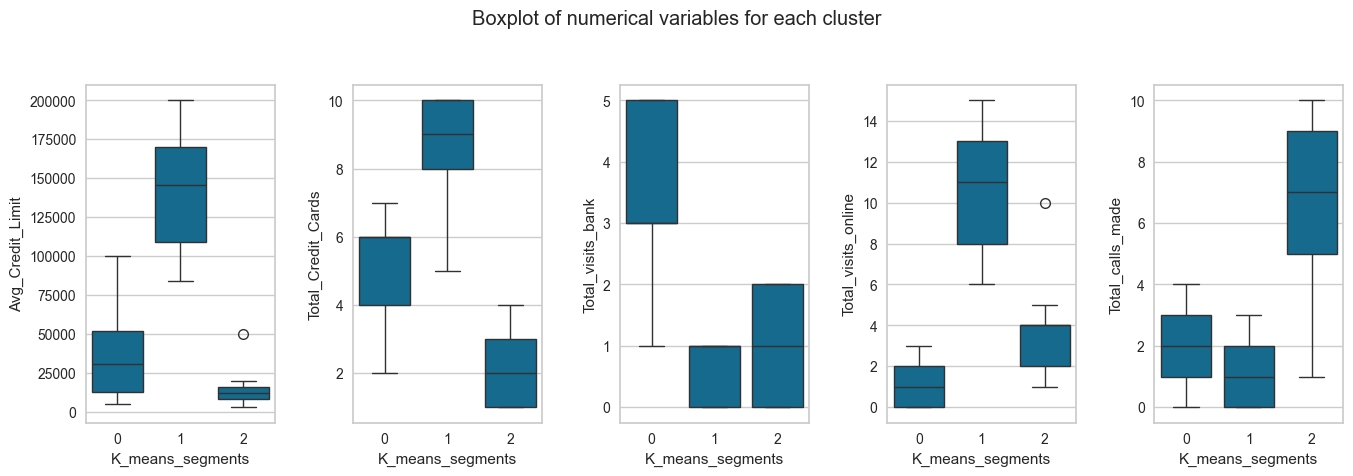

In [31]:
fig, axes = plt.subplots(1, 5, figsize=(14, 5))
fig.suptitle("Boxplot of numerical variables for each cluster")
counter = 0
for ii in range(5):
    sns.boxplot(ax=axes[ii], y=df[num_cols[counter]], x=df["K_means_segments"])
    counter = counter + 1

fig.tight_layout(pad=2.0)

***Observations***

***Cluster 0***
- *This cluster contains customers with medium credit limit, median is around 28K*
- *Total number of credit cards are between 4-6*
- *Number of bank visits is highest, and online visit is lowest, with medium calls to bank*
    
***Cluster 1***
- *Average credit limit is highest and number of cards is also highest*
- *Number of Bank visits is lowest and online is most active and calls made is also least*
    
***Cluster 2***
- *Average credit Limit is lowest, and so number of cards is also lowest*
- *Bank visits is medium, online visits is also medium, but calls made is highest*


#### ***Hierarchical Clustering***

***Let's find the Cophenetic correlation for different distances with different linkage methods.***

***What is Cophenetic correlation?***

***Find best combination of distance metrics and linkage method for hierarchical cluster - the one that yieids the highest cophenetic correlation coefficient***

In [32]:
# list of distance metrics
distance_metrics = ["euclidean", "chebyshev", "mahalanobis", "cityblock"]

# list of linkage methods
linkage_methods = ["single", "complete", "average", "weighted"]

high_cophenet_corr = 0
high_dm_lm = [0, 0]

for dm in distance_metrics:
    for lm in linkage_methods:
        Z = linkage(subset_scaled_df_hca, metric=dm, method=lm)
        c, coph_dists = cophenet(Z, pdist(subset_scaled_df_hca))
        print(
            "Cophenetic correlation for {} distance and {} linkage is {}.".format(
                dm.capitalize(), lm, c
            )
        )
        if high_cophenet_corr < c:
            high_cophenet_corr = c
            high_dm_lm[0] = dm
            high_dm_lm[1] = lm
    print()

Cophenetic correlation for Euclidean distance and single linkage is 0.7391220243806551.
Cophenetic correlation for Euclidean distance and complete linkage is 0.8599730607972426.
Cophenetic correlation for Euclidean distance and average linkage is 0.8977080867389374.
Cophenetic correlation for Euclidean distance and weighted linkage is 0.8861746814895478.

Cophenetic correlation for Chebyshev distance and single linkage is 0.7382354769296767.
Cophenetic correlation for Chebyshev distance and complete linkage is 0.8533474836336782.
Cophenetic correlation for Chebyshev distance and average linkage is 0.8973758299346933.
Cophenetic correlation for Chebyshev distance and weighted linkage is 0.8913624010768602.

Cophenetic correlation for Mahalanobis distance and single linkage is 0.7058064784553605.
Cophenetic correlation for Mahalanobis distance and complete linkage is 0.6663534463875358.
Cophenetic correlation for Mahalanobis distance and average linkage is 0.8326994115042133.
Cophenetic 

In [33]:
# printing the combination of distance metric and linkage method with the highest cophenetic correlation
print(
    "Highest cophenetic correlation is {}, which is obtained with {} distance and {} linkage.".format(
        high_cophenet_corr, high_dm_lm[0].capitalize(), high_dm_lm[1]
    )
)

Highest cophenetic correlation is 0.8977080867389374, which is obtained with Euclidean distance and average linkage.


***Exploring different linkage methods with Euclidean distance.***

In [34]:
# list of linkage methods
linkage_methods = ["single", "complete", "average", "centroid", "ward", "weighted"]

high_cophenet_corr = 0
high_dm_lm = [0, 0]

for lm in linkage_methods:
    Z = linkage(subset_scaled_df_hca, metric="euclidean", method=lm)
    c, coph_dists = cophenet(Z, pdist(subset_scaled_df_hca))
    print("Cophenetic correlation for {} linkage is {}.".format(lm, c))
    if high_cophenet_corr < c:
        high_cophenet_corr = c
        high_dm_lm[0] = "euclidean"
        high_dm_lm[1] = lm

Cophenetic correlation for single linkage is 0.7391220243806551.
Cophenetic correlation for complete linkage is 0.8599730607972426.
Cophenetic correlation for average linkage is 0.8977080867389374.
Cophenetic correlation for centroid linkage is 0.8938587282380298.
Cophenetic correlation for ward linkage is 0.7415691616273917.
Cophenetic correlation for weighted linkage is 0.8861746814895478.


In [35]:
# printing linkage method with the highest cophenetic correlation
print(
    "Highest cophenetic correlation is {}, which is obtained with {} linkage.".format(
        high_cophenet_corr, high_dm_lm[1]
    )
)

Highest cophenetic correlation is 0.8977080867389374, which is obtained with average linkage.


***The cophenetic correlation with Euclidean distance and average linkage is highest***

***Let's see the dendrograms for the different linkage methods.***

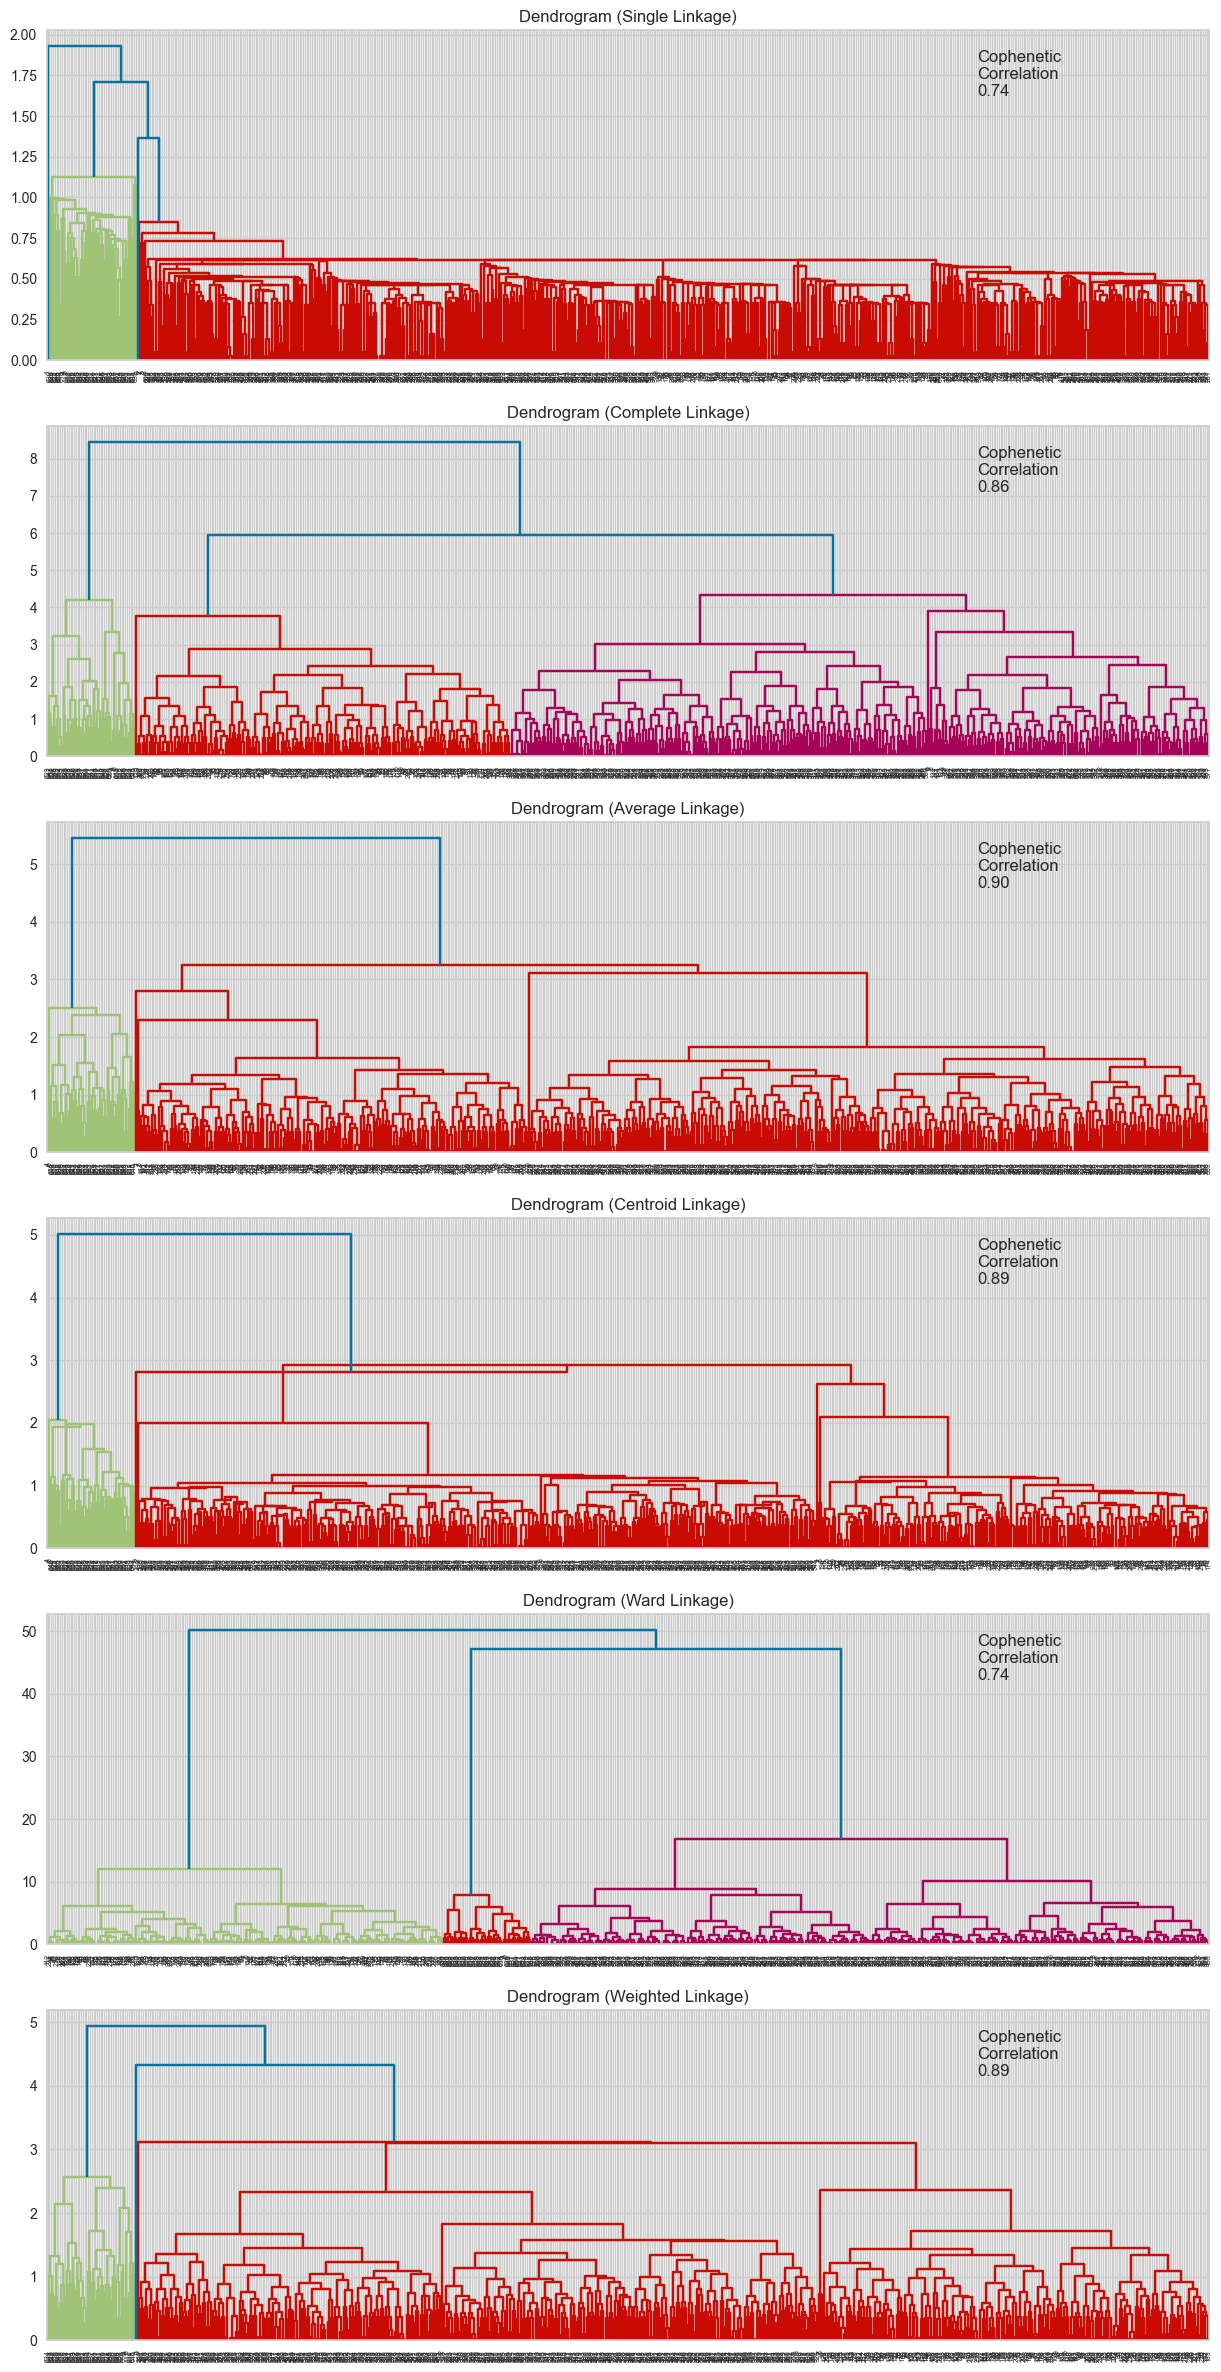

In [36]:
# list of linkage methods
linkage_methods = ["single", "complete", "average", "centroid", "ward", "weighted"]

# lists to save results of cophenetic correlation calculation
compare_cols = ["Linkage", "Cophenetic Coefficient"]
compare = []

# to create a subplot image
fig, axs = plt.subplots(len(linkage_methods), 1, figsize=(15, 30))

# We will enumerate through the list of linkage methods above
# For each linkage method, we will plot the dendrogram and calculate the cophenetic correlation
for i, method in enumerate(linkage_methods):
    Z = linkage(subset_scaled_df_hca, metric="euclidean", method=method)

    dendrogram(Z, ax=axs[i])
    axs[i].set_title(f"Dendrogram ({method.capitalize()} Linkage)")

    coph_corr, coph_dist = cophenet(Z, pdist(subset_scaled_df_hca))
    axs[i].annotate(
        f"Cophenetic\nCorrelation\n{coph_corr:0.2f}",
        (0.80, 0.80),
        xycoords="axes fraction",
    )

    compare.append([method, coph_corr])

- ***Dendrogram for Ward linkage shows distinct and separate clusters.***
- ***Also Dendrogram hight is max for 3 clusters***

In [37]:
# let's create a dataframe to compare cophenetic correlations for each linkage method
df_cc = pd.DataFrame(compare, columns=compare_cols)
df_cc

,Linkage,Cophenetic Coefficient
0,single,0.739
1,complete,0.860
2,average,0.898
3,centroid,0.894
4,ward,0.742
5,weighted,0.886


Let's see the dendrogram for Mahalanobis and Manhattan distances with average and weighted linkage methods (as they gave high cophenetic correlation values).

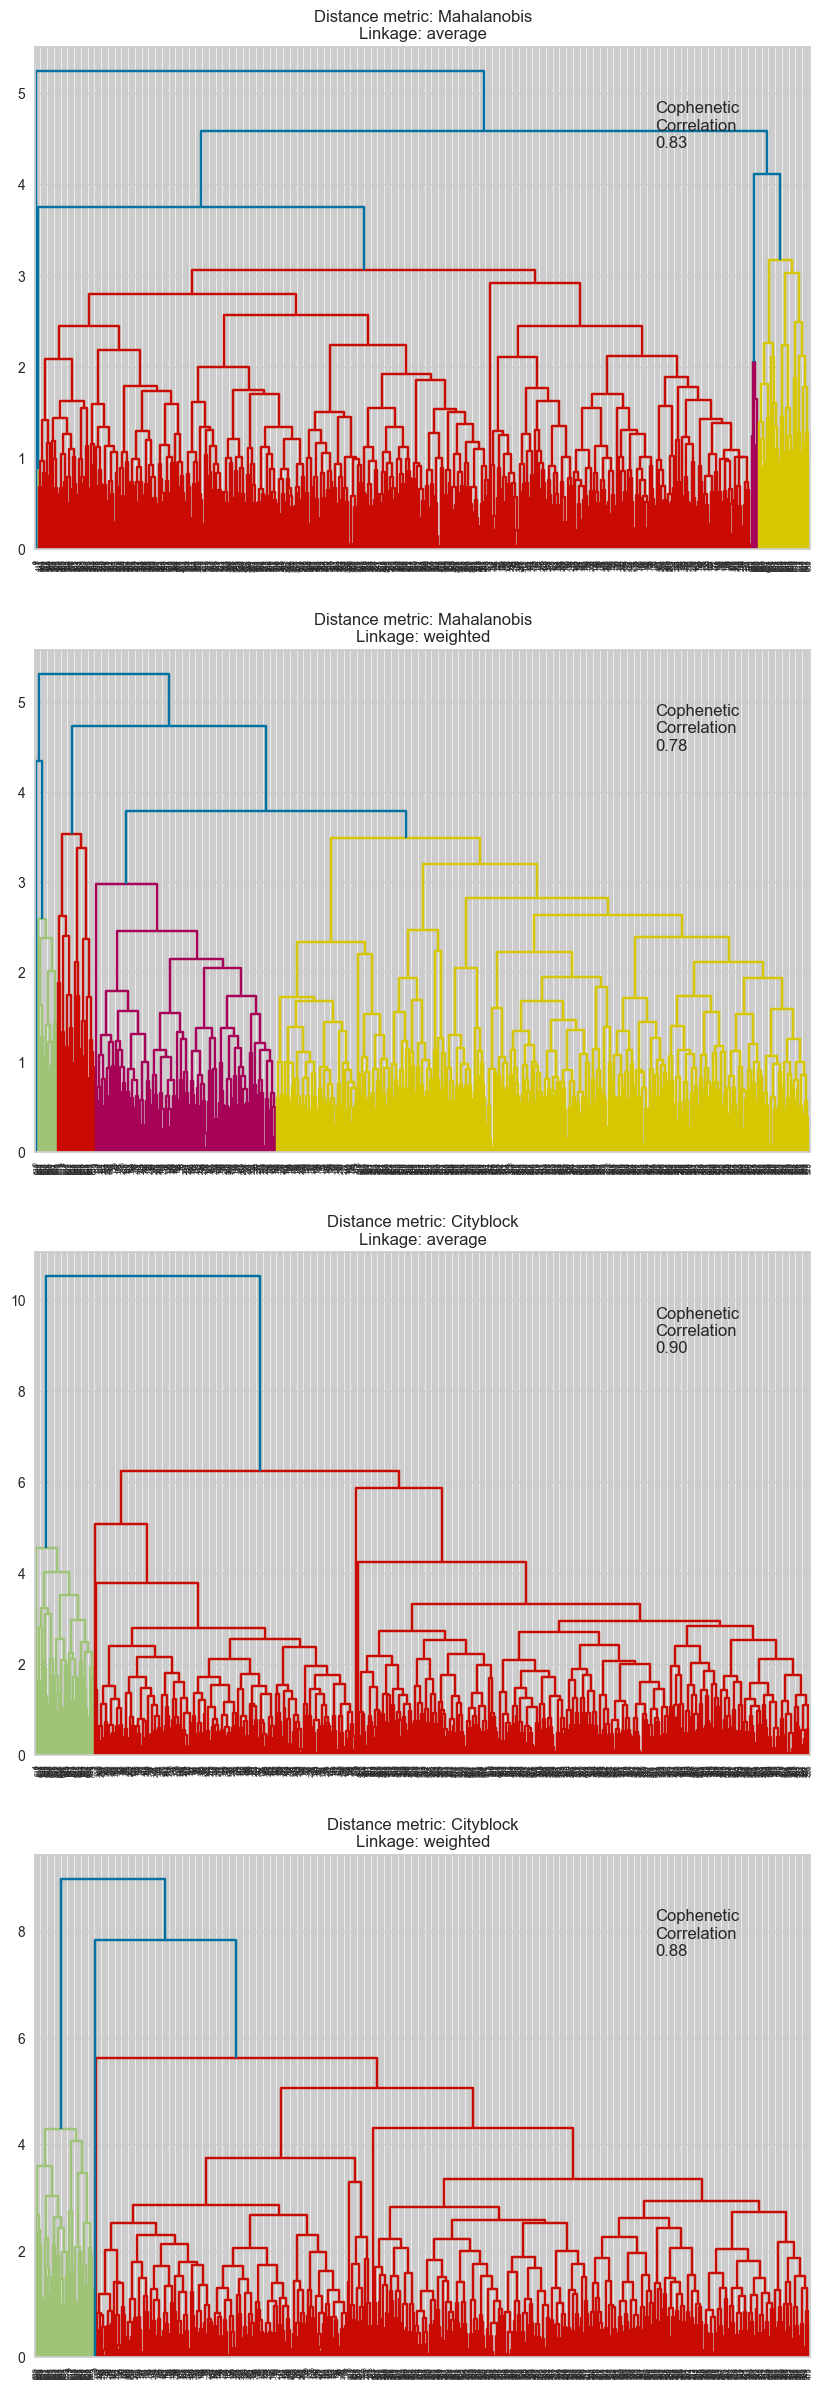

In [38]:
# list of distance metrics
distance_metrics = ["mahalanobis", "cityblock"]

# list of linkage methods
linkage_methods = ["average", "weighted"]

# to create a subplot image
fig, axs = plt.subplots(
    len(distance_metrics) + len(distance_metrics), 1, figsize=(10, 30)
)

i = 0
for dm in distance_metrics:
    for lm in linkage_methods:
        Z = linkage(subset_scaled_df_hca, metric=dm, method=lm)

        dendrogram(Z, ax=axs[i])
        axs[i].set_title("Distance metric: {}\nLinkage: {}".format(dm.capitalize(), lm))

        coph_corr, coph_dist = cophenet(Z, pdist(subset_scaled_df_hca))
        axs[i].annotate(
            f"Cophenetic\nCorrelation\n{coph_corr:0.2f}",
            (0.80, 0.80),
            xycoords="axes fraction",
        )
        i += 1

- ***Out of all the dendrograms we saw, it is clear that the dendrogram with Ward linkage gave us separate and distinct clusters.***
- ***3 would be the appropriate number of the clusters from the dendrogram with Ward linkage method.*** 

In [39]:
HCmodel = AgglomerativeClustering(n_clusters=3, metric="euclidean", linkage="ward")
HCmodel.fit(subset_scaled_df_hca)

,n_clusters,3
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


In [40]:
# adding hierarchical cluster labels to the original and scaled dataframes

subset_scaled_df_hca["HC_Clusters"] = HCmodel.labels_
df_hca["HC_Clusters"] = HCmodel.labels_

#### ***Cluster Profiling based on Hierarchical Clustering***

In [41]:
cluster_profile_hca = df_hca.groupby("HC_Clusters").mean()

In [42]:
cluster_profile_hca["count_in_each_segments"] = (
    df_hca.groupby("HC_Clusters")["Total_Credit_Cards"].count().values
)

In [43]:
# let's display cluster profiles
cluster_profile_hca.style.highlight_max(color="lightgreen", axis=0)

,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,count_in_each_segments
HC_Clusters,,,,,,,
0,54895.745455,33851.948052,5.516883,3.493506,0.979221,1.994805,385
1,55213.568889,12151.111111,2.422222,0.937778,3.546667,6.857778,225
2,56708.760000,141040.000000,8.740000,0.600000,10.900000,1.080000,50


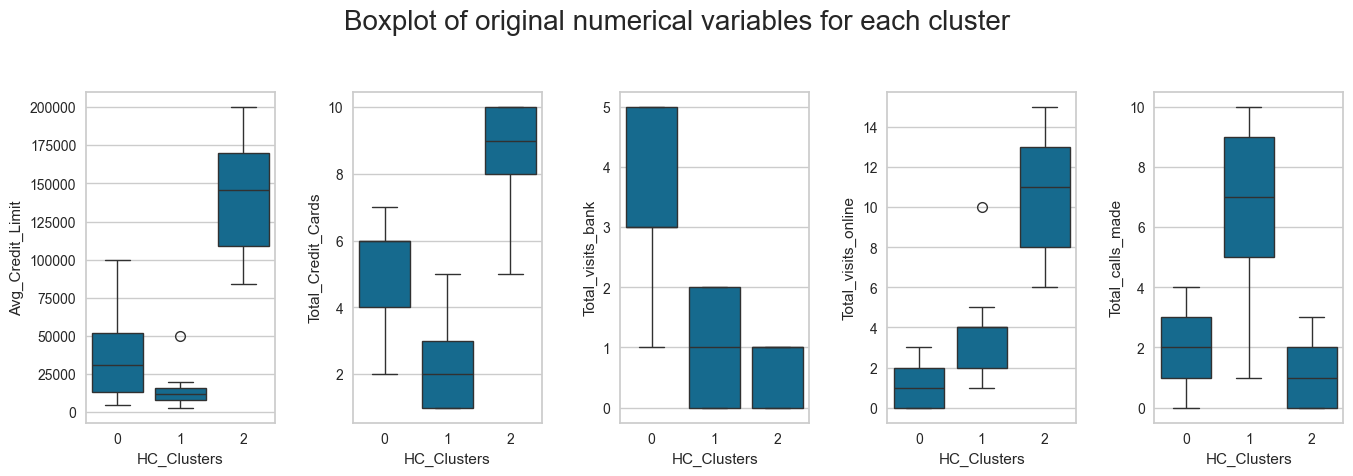

In [44]:
fig, axes = plt.subplots(1, 5, figsize=(14, 5))
fig.suptitle("Boxplot of original numerical variables for each cluster", fontsize=20)
counter = 0
for ii in range(5):
    sns.boxplot(ax=axes[ii], y=df_hca[num_cols[counter]], x=df_hca["HC_Clusters"])
    counter = counter + 1

fig.tight_layout(pad=2.0)

***Observations***

***Cluster 0***
- *This cluster contains customers with medium credit limit, median is around 28K*
- *Total number of credit cards are between 4-6*
- *Number of bank visits is highest, and online visit is lowest, with medium calls to bank*
    
***Cluster 1***
- *Average credit Limit is lowest, and so number of cards is also lowest*
- *Bank visits is medium, online visits is also medium, but calls made is highest*

***Cluster 2***
- *Average credit limit is highest and number of cards is also highest*
- *Number of Bank visits is lowest and online is most active and calls made is also least*

#### ***K-means vs Hierarchical Clustering***
- ***Both K Means and HCA gave similar results, other than swapping the cluster 1 and 2***

#### ***Recommendations***
- ***`Cluster 2` customers have highest credit limit and they are more likely to have more credit cards. They can be offered more cards. They like to operate more online, so bank should provide them with world class online facilities.*** 
- ***`Cluster 1` (based on HCA) have lowest credit limits and they don't have many cards. These types of customers, don't have many credit cards, so if customer already have credit cards, then there is less chance of taking more cards.*** 
- ***`Cluster 0` (based on HCA) are frequent visitors of bank, so bank should provide them with good experience at the banks and provide good plans at the banks***